## Step 1: Import Libraries and Load Dataset

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


#### Display random sample images

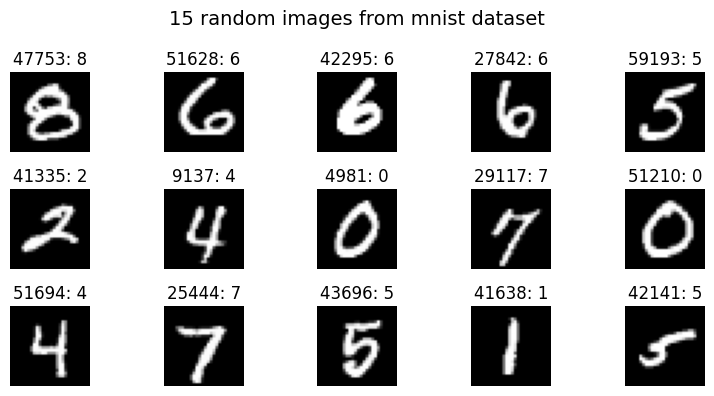

In [22]:
import random

plt.figure(figsize=(8, 4))
plt.suptitle('15 random images from mnist dataset', fontsize = 14)
row, col, cnt = 3, 5, 1   # subplot: row coulumn counter

for i in random.sample(range(len(train_images)), 15):
    plt.subplot(row, col, cnt)
    plt.imshow(train_images[i].reshape(28, 28), cmap = 'gray')
    plt.title('{}: {}'.format(i, train_labels[i]))
    plt.axis('off')
    cnt = cnt + 1

plt.tight_layout()
plt.show()


## Step 2: Preprocess the Data

In [23]:
# Normalize images to values between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0


In [24]:
# Reshape images to (28, 28, 1) for CNN input
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [25]:
# Convert labels to one-hot encoded format
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

print(f"Normalized and reshaped training images shape: {train_images.shape}")
print(f"One-hot encoded training labels shape: {train_labels.shape}")
print(f"Normalized and reshaped test images shape: {test_images.shape}")
print(f"One-hot encoded test labels shape: {test_labels.shape}")

Normalized and reshaped training images shape: (60000, 28, 28, 1)
One-hot encoded training labels shape: (60000, 10)
Normalized and reshaped test images shape: (10000, 28, 28, 1)
One-hot encoded test labels shape: (10000, 10)


## Step 3: Build the CNN Model

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the Model

In [27]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    batch_size=64
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 64ms/step - accuracy: 0.9094 - loss: 0.2936 - val_accuracy: 0.9799 - val_loss: 0.0621
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9670 - loss: 0.1106 - val_accuracy: 0.9853 - val_loss: 0.0433
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - accuracy: 0.9747 - loss: 0.0833 - val_accuracy: 0.9882 - val_loss: 0.0344
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9788 - loss: 0.0697 - val_accuracy: 0.9888 - val_loss: 0.0309
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 61ms/step - accuracy: 0.9806 - loss: 0.0630 - val_accuracy: 0.9899 - val_loss: 0.0302
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.9832 - loss: 0.0559 - val_accuracy: 0.9902 - val_loss: 0.0279
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9844 - loss: 0.0520 - val_accuracy: 0.9916 - val_loss: 0.0232
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 64ms/step - accuracy: 0.9853 - loss: 0.0473 - 

## Step 5: Evaluate the Model

In [28]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_images, test_labels, verbose=2)

print(f"\nTest loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

313/313 - 2s - 8ms/step - accuracy: 0.9925 - loss: 0.0234

Test loss: 0.0234
Test accuracy: 0.9925


## Step 6: Test the Model with Custom Images


Custom image shape after preprocessing: (1, 28, 28, 1)


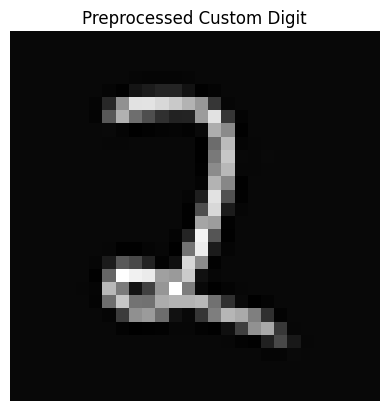

In [29]:
from PIL import Image
import os

def preprocess_custom_image(image_path):
    # Load the image and convert to grayscale
    img = Image.open(image_path).convert('L')

    # Resize to 28x28 pixels
    img = img.resize((28, 28))

    # Convert to numpy array and normalize
    img_array = np.array(img)
    img_array = img_array.astype('float32') / 255.0

    if np.mean(img_array) > 0.5: # Simple heuristic: if image is mostly white, invert
        img_array = 1 - img_array

    # Reshape for CNN input (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array

# Example usage with an uploaded image named 'custom_digit.png'
# Make sure you upload your image file to the Colab environment first.
custom_image_path = '/content/2.png'

if os.path.exists(custom_image_path):
    custom_digit = preprocess_custom_image(custom_image_path)
    print(f"Custom image shape after preprocessing: {custom_digit.shape}")

    # Display the preprocessed image (optional, for verification)
    plt.imshow(custom_digit.reshape(28, 28), cmap='gray')
    plt.title('Preprocessed Custom Digit')
    plt.axis('off')
    plt.show()

else:
    print(f"Error: {custom_image_path} not found. Please upload your custom image file.")
    custom_digit = None # Set to None if image not found


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Model prediction: 2
Prediction probabilities: [1.09312765e-04 3.46319154e-02 9.43946898e-01 9.80008021e-03
 4.78615402e-05 5.43616352e-06 5.68446812e-05 1.07555250e-02
 4.88476595e-04 1.57633767e-04]


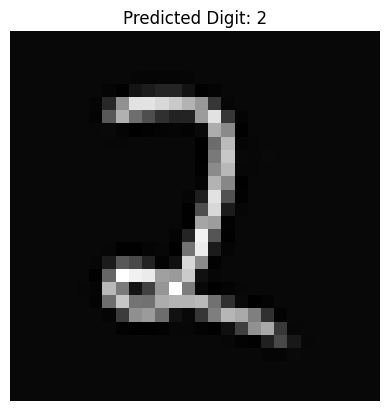

In [30]:
if custom_digit is not None:
    # Make a prediction
    predictions = model.predict(custom_digit)
    predicted_class = np.argmax(predictions)

    print(f"Model prediction: {predicted_class}")
    print(f"Prediction probabilities: {predictions[0]}")

    # Display the result visually
    plt.imshow(custom_digit.reshape(28, 28), cmap='gray')
    plt.title(f'Predicted Digit: {predicted_class}')
    plt.axis('off')
    plt.show()
else:
    print("Cannot make a prediction without a preprocessed custom image.")

### Summary of Custom image prediction


Predicted digit: 2
Prediction probabilities: [1.09312765e-04 3.46319154e-02 9.43946898e-01 9.80008021e-03
 4.78615402e-05 5.43616352e-06 5.68446812e-05 1.07555250e-02
 4.88476595e-04 1.57633767e-04]


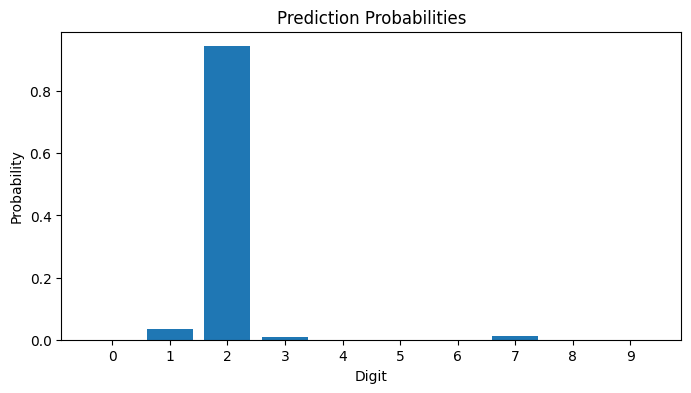

In [31]:
if custom_digit is not None:
    predicted_class = np.argmax(predictions)
    print(f"Predicted digit: {predicted_class}")
    print(f"Prediction probabilities: {predictions[0]}")

    # Optionally, you can also visualize the probability distribution
    plt.figure(figsize=(8, 4))
    plt.bar(range(10), predictions[0], tick_label=range(10))
    plt.title('Prediction Probabilities')
    plt.xlabel('Digit')
    plt.ylabel('Probability')
    plt.show()
else:
    print("No custom image was processed, so no predictions to summarize.")